In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/customers_final.csv")
print(df.shape)
df.info()
df.head()

(7043, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                7043 non-null   object 
 1   tenure_months              7043 non-null   int64  
 2   plan_type                  7043 non-null   object 
 3   monthly_charges            7043 non-null   float64
 4   total_charges              7043 non-null   float64
 5   internet_service           7043 non-null   object 
 6   payment_method             7043 non-null   object 
 7   n_complaints_30d           7043 non-null   int64  
 8   severity                   7043 non-null   object 
 9   reopen_count               7043 non-null   int64  
 10  open_unresolved_count      7043 non-null   int64  
 11  n_contacts_30d             7043 non-null   int64  
 12  channel                    7043 non-null   object 
 13  n_repeat_contacts          7043 non-n

,customer_id,tenure_months,plan_type,monthly_charges,total_charges,internet_service,payment_method,n_complaints_30d,severity,reopen_count,...,n_repeat_contacts,escalation_count,first_contact_resolved,avg_resolution_hours,max_resolution_hours,sla_breached,pending_age_days,csat_score,days_since_last_complaint,churned
0,CUST-1000,2,Month-to-month,53.85,108.15,DSL,Mailed check,0,Low,0,...,0,1,0,5.8,12.8,0,0.0,2.4,133,1
1,CUST-1001,2,Month-to-month,70.70,151.65,Fiber optic,Electronic check,1,Low,1,...,1,0,0,7.4,29.5,0,0.0,4.3,4,1
2,CUST-1002,8,Month-to-month,99.65,820.50,Fiber optic,Electronic check,1,Low,0,...,1,1,1,14.2,21.8,0,0.6,2.4,18,1
3,CUST-1003,28,Month-to-month,104.80,3046.05,Fiber optic,Electronic check,1,Low,0,...,0,0,1,33.9,61.6,0,0.2,4.2,7,1
4,CUST-1004,49,Month-to-month,103.70,5036.30,Fiber optic,Bank transfer (automatic),3,Low,1,...,0,1,1,31.4,60.8,0,0.0,5.0,27,1


churned
0    73.463013
1    26.536987
Name: proportion, dtype: float64


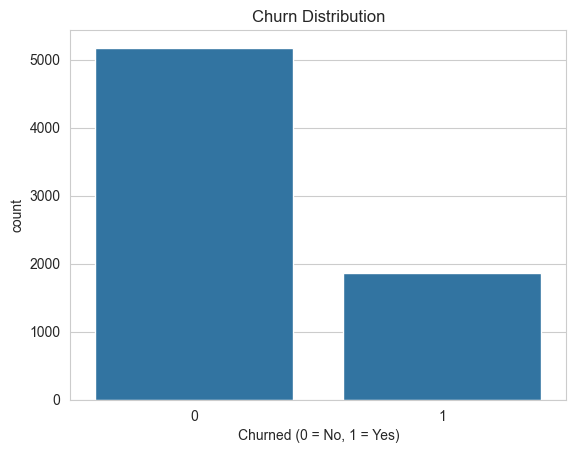

In [8]:
churn_counts = df["churned"].value_counts(normalize=True) * 100
print(churn_counts)

sns.countplot(data=df, x="churned")
plt.title("Churn Distribution")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.show()

**Observation:** Churn rate is ~26.5%, confirming this is an imbalanced
classification problem. A model that always predicted "no churn" would
already score ~73% accuracy while catching zero actual churners — this
is exactly why the brief requires recall, precision, and F1 for the
churn class instead of relying on accuracy (§7).

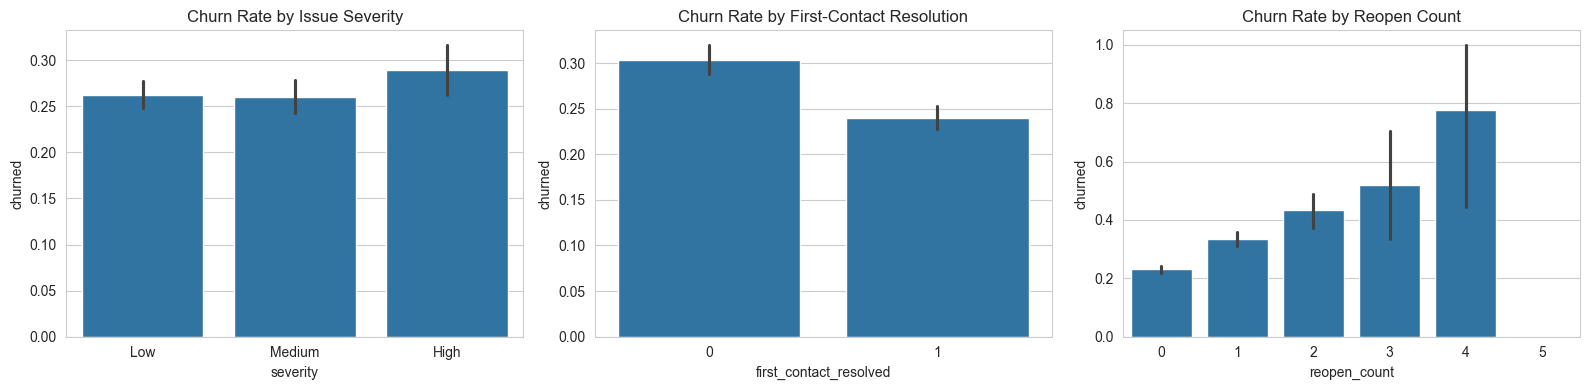

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=df, x="severity", y="churned", ax=axes[0])
axes[0].set_title("Churn Rate by Issue Severity")

sns.barplot(data=df, x="first_contact_resolved", y="churned", ax=axes[1])
axes[1].set_title("Churn Rate by First-Contact Resolution")

sns.barplot(data=df, x="reopen_count", y="churned", ax=axes[2])
axes[2].set_title("Churn Rate by Reopen Count")

plt.tight_layout()
plt.show()

**Observation:** Churn rate by severity is fairly flat (~0.26 for Low/
Medium, ~0.29 for High) with overlapping error bars — severity alone is
a weak signal here. First-contact resolution shows a clearer pattern:
customers whose issue was NOT resolved on first contact churn at ~30%
vs. ~24% for those who were resolved on first contact. Reopen count
shows the strongest trend of the three — churn rises steadily from
~23% at 0 reopens to ~77% at 4 reopens, though the wide error bars at
higher reopen counts reflect a small sample size there and should be
read cautiously.

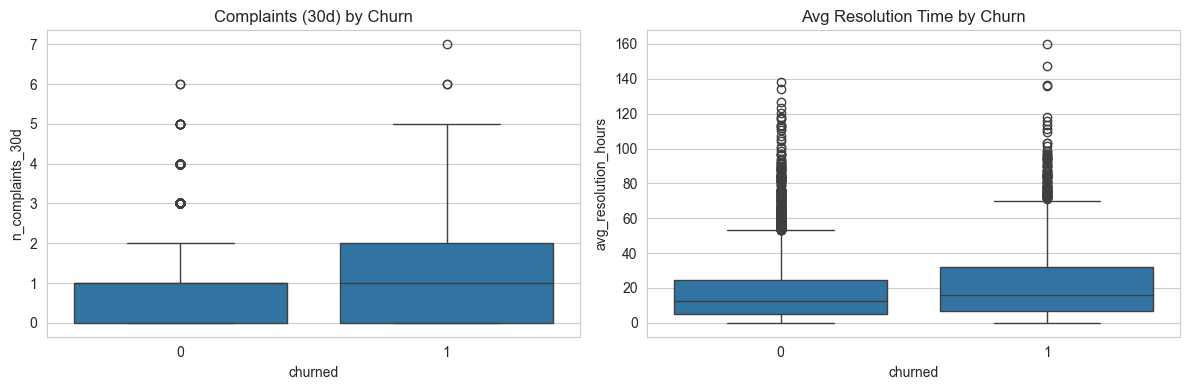

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="churned", y="n_complaints_30d", ax=axes[0])
axes[0].set_title("Complaints (30d) by Churn")

sns.boxplot(data=df, x="churned", y="avg_resolution_hours", ax=axes[1])
axes[1].set_title("Avg Resolution Time by Churn")

plt.tight_layout()
plt.show()

**Observation:** Churned customers show a higher median complaint count
(1 vs. 0) and a wider spread (IQR 0–2 vs. 0–1) than non-churned
customers. Average resolution time follows the same pattern — churned
customers have a slightly higher median (~15 hrs vs. ~12 hrs) and a
wider IQR (0–31 vs. 0–24). Both distributions overlap substantially, so
these are contributing signals rather than sharp dividers between the
two groups.

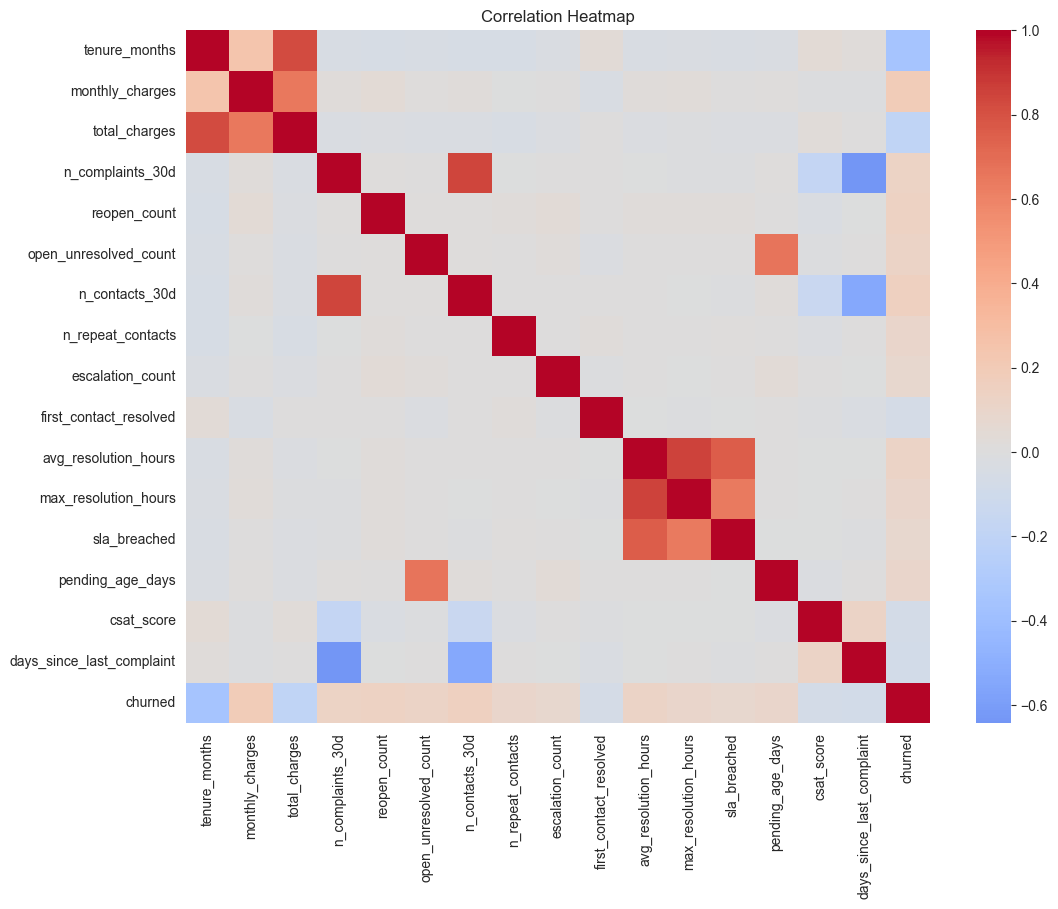

churned                      1.000000
monthly_charges              0.193356
n_contacts_30d               0.149792
reopen_count                 0.136824
n_complaints_30d             0.131570
open_unresolved_count        0.116206
avg_resolution_hours         0.115324
n_repeat_contacts            0.100243
max_resolution_hours         0.100150
pending_age_days             0.097168
escalation_count             0.087819
sla_breached                 0.087654
first_contact_resolved      -0.070885
csat_score                  -0.074548
days_since_last_complaint   -0.078525
total_charges               -0.199037
tenure_months               -0.352229
Name: churned, dtype: float64


In [11]:
numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Flag anything suspiciously close to a perfect predictor
print(corr["churned"].sort_values(ascending=False))

**Observation:** Numeric correlations with `churned` range from about
-0.35 to 0.19, with tenure_months (-0.35) as the strongest single
signal, followed by monthly_charges (0.19) and the contact/complaint
fields (0.10–0.15). No feature approaches 0.9+, which would indicate
target leakage — the synthetic service-issue fields were deliberately
generated with mild, noisy correlation to churn rather than as a direct
function of it, so this range is expected and confirms the leakage
check passed. The heatmap also shows the resolution-time fields
(avg/max_resolution_hours, sla_breached) are correlated with each
other, as expected since they're derived from the same underlying
resolution process.

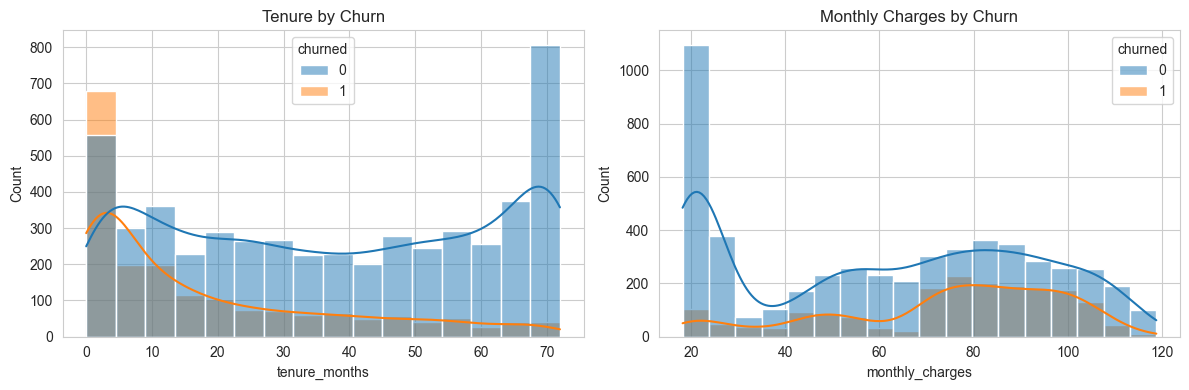

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="tenure_months", hue="churned", kde=True, ax=axes[0])
axes[0].set_title("Tenure by Churn")

sns.histplot(data=df, x="monthly_charges", hue="churned", kde=True, ax=axes[1])
axes[1].set_title("Monthly Charges by Churn")

plt.tight_layout()
plt.show()

**Observation:** Churned customers (orange) are heavily concentrated at
low tenure and drop off sharply as tenure increases, while non-churned
customers (blue) are more evenly spread and even show a second peak at
high tenure (~70 months) — long-tenured customers rarely churn. This
matches the -0.35 correlation found in Cell 5, the strongest signal in
the dataset. For monthly charges, non-churned customers peak sharply at
low charges (~20), while churned customers are more concentrated in the
60–100 range — higher-paying customers churn more, consistent with
monthly_charges' positive 0.19 correlation.